## Import Dependencies

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Concatenate, Dropout
from transformers import BertTokenizer, TFBertModel
from tensorflow.keras.applications import EfficientNetB0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

## Loading the dataset

In [ ]:
df=pd.read_csv('categorized_df.csv')


In [ ]:
# Since model can not process the image in row 184, I omitted that row to make both text and image reviwes with similar count
df=df.drop(184)

## Using BERT for tokenize and embedding the text modality

In [ ]:
import re

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
def preprocess_for_abstractive(text, max_length=512):
    # Convert to lowercase
    if not isinstance(text, str):
        return ''
    text = text.lower()

    # Remove URLs and HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    # Tokenize and truncate to max_length
    tokens = nltk.word_tokenize(text)
    tokens = tokens[:max_length]  # Truncate

    # Join tokens back into text
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text

In [ ]:
df['preprocess_text']=df['text'].apply(preprocess_for_abstractive)

In [ ]:
text_reviews=df['preprocess_text'].to_list()

In [ ]:
# Tokenizer and pre-trained BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = TFBertModel.from_pretrained("bert-base-uncased")

# Process text reviews
def process_text(texts):
    tokens = tokenizer(texts, padding=True, truncation=True, max_length=250, return_tensors="tf")
    outputs = bert_model(tokens)
    return outputs.last_hidden_state[:, 0, :]  # Use [CLS] token embedding

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [ ]:
text_features = process_text(text_reviews) # text_reviews: list of text data

In [ ]:
text_features

<tf.Tensor: shape=(499, 768), dtype=float32, numpy=
array([[-0.20966974,  0.38183242, -0.19246306, ..., -0.14014563,
         0.20161992,  0.45293218],
       [-0.32510155,  0.19051436,  0.47079635, ..., -0.17335127,
         0.50787246,  0.5572652 ],
       [-0.29099643, -0.00232509,  0.22347149, ..., -0.1273033 ,
         0.23169771,  0.31231546],
       ...,
       [ 0.02408814,  0.05764887, -0.24798673, ..., -0.22843406,
         0.36463302,  0.55277574],
       [-1.0534027 , -0.41769797, -0.37494645, ..., -0.37309587,
        -0.38231966,  0.3368985 ],
       [-0.24010146, -0.4618206 ,  0.3995115 , ..., -0.4602872 ,
         0.5507778 ,  0.10819913]], dtype=float32)>

## Image processing

## Extracting Large images

In [ ]:
import ast

# Step 1: Convert strings to Python objects
df['images_parsed'] = df['images'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
# Count the number of images per review
df['image_count'] = df['images_parsed'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Summary statistics
print(df['image_count'].describe())


count    499.000000
mean       1.775551
std        1.227907
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        9.000000
Name: image_count, dtype: float64


In [ ]:
# for reviews which have more than one large image, we want to just get one
def get_first_image(images):
    if isinstance(images, list) and images:
        return images[0].get('large_image_url', None)  # Get 'large_image_url' from the first image
    return None

In [ ]:
df['selected_image'] = df['images_parsed'].apply(get_first_image)

In [ ]:
#  Extract large image URLs
def extract_large_urls(image_column):
    urls = []
    for image_list in image_column:
        if isinstance(image_list, list):  # Ensure it's a list
            for image_dict in image_list:
                if isinstance(image_dict, dict) and 'large_image_url' in image_dict:
                    urls.append(image_dict['large_image_url'])
    return urls

In [ ]:
# Example dataframe column containing image data
#image_column = df['images']  # Replace 'images' with your dataframe's column name
large_image_urls = df['selected_image'].to_list()

In [ ]:
!pip install requests

In [ ]:
import requests
from PIL import Image
from io import BytesIO

In [ ]:
# 2. Download and preprocess images
# def download_and_preprocess_image(url, target_size=(224, 224)):
#     try:
#         response = requests.get(url, timeout=10)
#         response.raise_for_status()
#         image = Image.open(io.BytesIO(response.content)).convert("RGB")  # Convert to RGB
#         image = image.resize(target_size)  # Resize to target size
#         image_array = np.array(image)  # Convert to NumPy array
#         image_array = preprocess_input(image_array)  # Normalize for EfficientNet
#         return image_array
#     except Exception as e:
#         print(f"Failed to process image from URL {url}: {e}")
#         return None

def fetch_images_from_urls(urls):
    images = []
    for url in urls:
        try:
            # Fetch the image from the URL
            response = requests.get(url)
            response.raise_for_status()  # Raise an error for HTTP issues
            # Open the image using PIL
            image = Image.open(BytesIO(response.content))
            images.append(image)
        except Exception as e:
            print(f"Failed to process image from URL {url}: {e}")
    return images


In [ ]:
# Fetch the images from the URLs
image_objects = fetch_images_from_urls(large_image_urls)

# Check the results
print(f"Number of images fetched: {len(image_objects)}")

Number of images fetched: 499


In [ ]:
image_objects

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x1600>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x1600>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x1600>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1527x1309>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x1600>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x1600>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1632x1224>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=320x240>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1152x875>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x1600>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x1600>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1224x1632>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x1600>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1600x1200>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB 

In [ ]:
import numpy as np
from PIL import Image

# Target size for resizing
target_size = (224, 224)

# Prepare the image data
image_data = []
for img in image_objects:
    try:
        # Resize image to target size
        resized_img = img.resize(target_size)
        # Convert image to NumPy array
        img_array = np.array(resized_img)  # Shape: (224, 224, 3)
        image_data.append(img_array)
    except Exception as e:
        print(f"Error processing image {img}: {e}")

In [ ]:
# Stack all images into a single NumPy array
image_data = np.stack(image_data)  # Shape: (num_images, 224, 224, 3)

print(f"Image data shape: {image_data.shape}")

Image data shape: (499, 224, 224, 3)


In [ ]:
target_value = "https://images-na.ssl-images-amazon.com/images/I/71t3CM-vZRL.jpg"

# Find the index
try:
    index = large_image_urls.index(target_value)
    print(f"The index of '{target_value}' is {index}.")
except ValueError:
    print(f"'{target_value}' is not in the list.")

The index of 'https://images-na.ssl-images-amazon.com/images/I/71t3CM-vZRL.jpg' is 184.


In [ ]:
# Pre-trained EfficientNet
from tensorflow.keras.applications import EfficientNetB7
base_cnn = EfficientNetB7(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
cnn_output = tf.keras.layers.GlobalAveragePooling2D()(base_cnn.output)
image_model = Model(inputs=base_cnn.input, outputs=cnn_output)

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
image_features = image_model.predict(image_data)  # image_data: preprocessed image array

16/16 ━━━━━━━━━━━━━━━━━━━━ 294s 18s/step


In [ ]:
image_features.shape

(499, 2560)

# Training the model

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
le = LabelEncoder()

# Fit and transform the target labels to integers
y_encoded = le.fit_transform(df['problem_of_product'])

# Use the encoded labels for splitting
y = y_encoded

In [ ]:
y

array([3, 0, 2, 2, 0, 4, 3, 0, 2, 3, 3, 0, 2, 2, 2, 0, 0, 3, 2, 2, 3, 2,
       2, 0, 2, 3, 2, 0, 3, 0, 2, 0, 1, 2, 2, 2, 0, 0, 4, 0, 3, 2, 3, 3,
       2, 3, 3, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 3, 0, 2, 2,
       2, 2, 0, 2, 4, 0, 0, 2, 2, 4, 2, 4, 2, 2, 2, 2, 0, 2, 3, 2, 3, 2,
       0, 0, 2, 2, 0, 2, 0, 3, 2, 4, 4, 3, 0, 3, 2, 2, 0, 2, 0, 0, 3, 3,
       0, 4, 4, 0, 3, 0, 2, 3, 2, 0, 0, 3, 0, 0, 0, 4, 3, 2, 3, 4, 2, 3,
       2, 3, 0, 0, 2, 2, 0, 2, 3, 3, 3, 2, 2, 3, 3, 2, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 3, 2, 2, 0, 3, 4, 0, 0, 2, 0, 0, 0, 0, 0, 3, 2, 3, 3,
       3, 2, 0, 2, 0, 3, 2, 0, 2, 1, 3, 2, 3, 0, 3, 4, 0, 2, 2, 2, 2, 0,
       2, 0, 4, 2, 0, 0, 0, 0, 4, 0, 2, 2, 3, 0, 1, 2, 0, 0, 2, 2, 0, 0,
       2, 0, 3, 2, 2, 0, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 0, 3, 4,
       2, 4, 2, 3, 2, 0, 2, 0, 0, 2, 0, 2, 2, 2, 0, 0, 3, 2, 2, 3, 0, 0,
       0, 1, 2, 0, 2, 1, 0, 3, 2, 2, 4, 3, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 4, 2, 3, 2, 0, 4, 3, 3, 3, 2, 0,

In [ ]:
from collections import Counter

counts = Counter(y)

# Display counts
for value, count in counts.items():
    print(f"Value {value} appears {count} times")

Value 3 appears 90 times
Value 0 appears 172 times
Value 2 appears 185 times
Value 4 appears 43 times
Value 1 appears 9 times


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Assuming your features are in numpy arrays: image_features and text_features
# image_features.shape = (499, 1280)
# text_features.shape = (499, 768)

scaler = MinMaxScaler()

# Fit and transform both image and text features
image_features_normalized = scaler.fit_transform(image_features)
text_features_normalized = scaler.fit_transform(text_features)

# Now the values of image_features_normalized and text_features_normalized are scaled to [0, 1]


## Early Fusion

In [ ]:
# Inputs
from tensorflow.keras.optimizers import Adam

text_input = Input(shape=(768,))  # BERT feature size
image_input = Input(shape=(2560,))  # EfficientNet feature size

# Fusion via concatenation
fused = Concatenate()([text_input, image_input])
fused = Dense(512, activation="relu")(fused)  # Additional dense layer
fused = Dropout(0.5)(fused)
output = Dense(5, activation="softmax")(fused)  # 5 categories

# Build the model
multimodal_model = Model(inputs=[text_input, image_input], outputs=output)

# Compile
multimodal_model.compile(optimizer=Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])


In [ ]:
from sklearn.model_selection import train_test_split

text_features = np.array(text_features_normalized)  # Ensure it's a NumPy array
image_features = np.array(image_features_normalized)  # Ensure it's a NumPy array
y = np.array(y)


# Assuming you already have your text_features and image_features
# Split the dataset into training and testing sets (80% train, 20% test)
text_features_train, text_features_test, image_features_train, image_features_test, y_train, y_test = train_test_split(
    text_features, image_features, y, test_size=0.1, random_state=42
)

In [ ]:
from keras.utils import to_categorical

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train, num_classes=5)  # Since you have 5 classes
y_test_one_hot = to_categorical(y_test, num_classes=5)

In [ ]:
# Combine features from text and image
X_train = [text_features_train, image_features_train]
X_test = [text_features_test, image_features_test]
class_weights = {0: 1, 1:20 , 2: 1, 3: 2, 4: 4}

# Train
multimodal_model.fit([text_features_train, image_features_train], y_train_one_hot, epochs=50, batch_size=32)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3224 - loss: 1.5767
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3996 - loss: 1.3878
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4129 - loss: 1.3505
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4028 - loss: 1.3500
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4365 - loss: 1.2645
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4535 - loss: 1.2417
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4861 - loss: 1.2037
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5200 - loss: 1.1631
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5410 - loss: 1.1454
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5362 - loss: 1.1647
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5746 - loss: 1.0878
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy:

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = multimodal_model.evaluate([text_features_test, image_features_test], y_test_one_hot)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5267 - loss: 1.4092 
Test Loss: 1.3770562410354614
Test Accuracy: 0.5400000214576721


In [ ]:
# Get predictions on the test set
predictions = multimodal_model.predict([text_features_test, image_features_test])

# If you want to convert predictions to class labels (since it's multi-class classification)
predicted_classes = predictions.argmax(axis=1)  # Get the index of the max probability for each sample

# Print the predicted classes
print(predicted_classes)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[2 0 2 0 2 3 0 2 2 0 0 2 2 0 0 0 3 2 2 0 3 2 2 2 0 2 3 2 3 3 0 0 0 3 2 4 2
 2 4 2 2 0 2 0 2 2 2 2 2 2]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels (from the one-hot encoded labels, convert to class indices)
true_classes = y_test_one_hot.argmax(axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report (precision, recall, f1-score)
class_report = classification_report(true_classes, predicted_classes)
print("Classification Report:")
print(class_report)


Confusion Matrix:
[[ 6  0  5  2  0]
 [ 0  0  1  0  0]
 [ 3  0 16  2  2]
 [ 5  0  4  1  0]
 [ 1  0  0  2  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.46      0.43        13
           1       0.00      0.00      0.00         1
           2       0.62      0.70      0.65        23
           3       0.14      0.10      0.12        10
           4       0.00      0.00      0.00         3

    accuracy                           0.46        50
   macro avg       0.23      0.25      0.24        50
weighted avg       0.42      0.46      0.44        50



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Comparing Early and Late Fusion

In [ ]:
import torch
import torch.nn as nn

class EarlyFusionModel(nn.Module):
    def __init__(self):
        super(EarlyFusionModel, self).__init__()

        # Fully connected layers for early fusion after concatenation of features
        self.fc1 = nn.Linear(2560 + 768, 1664)  # Image (2560) + Text (768) features
        self.fc2 = nn.Linear(1664, 832)
        self.fc3 = nn.Linear(832, 5)  # Assuming 5 problem categories

    def forward(self, text_features, image_features):
        # Concatenate text and image features
        combined = torch.cat((text_features, image_features), dim=1)

        # Pass through fully connected layers
        x = torch.relu(self.fc1(combined))
        x = torch.relu(self.fc2(x))
        output = self.fc3(x)

        return output

# Example usage
text_features = torch.rand(499, 768)  # Random example (your BERT features)
image_features = torch.rand(499, 2560)  # Random example (your CNN features)

model_early = EarlyFusionModel()

# Forward pass
output_early = model_early(text_features, image_features)
print(output_early.shape)  # Should print: torch.Size([499, 5])


torch.Size([499, 5])


In [ ]:
class LateFusionModel(nn.Module):
    def __init__(self):
        super(LateFusionModel, self).__init__()

        # Fully connected layers for the text model (Text features)
        self.text_fc1 = nn.Linear(768, 832)  # Text features (768)

        # Fully connected layers for the image model (Image features)
        self.image_fc1 = nn.Linear(2560, 832)  # Image features (1280)

        # Final fusion layer
        self.fc2 = nn.Linear(832 * 2, 832)  # Text + Image fusion (1024)
        self.fc3 = nn.Linear(832, 5)  # Assuming 5 problem categories

    def forward(self, text_features, image_features):
        # Process text features
        text_embeds = torch.relu(self.text_fc1(text_features))

        # Process image features
        image_embeds = torch.relu(self.image_fc1(image_features))

        # Concatenate text and image embeddings
        combined = torch.cat((text_embeds, image_embeds), dim=1)

        # Final fusion layer
        x = torch.relu(self.fc2(combined))
        output = self.fc3(x)

        return output

# Example usage
model_late = LateFusionModel()

# Forward pass
output_late = model_late(text_features, image_features)
print(output_late.shape)  # Should print: torch.Size([499, 5])


torch.Size([499, 5])


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split

# Assuming text_features_normalized, image_features_normalized, and y are NumPy arrays
text_features = np.array(text_features_normalized)  # Ensure it's a NumPy array
image_features = np.array(image_features_normalized)  # Ensure it's a NumPy array
y = np.array(y)  # Your labels

# Split the dataset into training and testing sets (80% train, 20% test)
text_features_train, text_features_test, image_features_train, image_features_test, y_train, y_test = train_test_split(
    text_features, image_features, y, test_size=0.1, random_state=42
)

# Convert NumPy arrays to PyTorch tensors
text_features_train = torch.tensor(text_features_train, dtype=torch.float32)
image_features_train = torch.tensor(image_features_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

text_features_test = torch.tensor(text_features_test, dtype=torch.float32)
image_features_test = torch.tensor(image_features_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(text_features_train, image_features_train, y_train)
test_dataset = TensorDataset(text_features_test, image_features_test, y_test)

# Create DataLoaders for train and test datasets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Epoch 1/50, Loss: 1.3898
Epoch 2/50, Loss: 1.3102
Epoch 3/50, Loss: 1.2983
Epoch 4/50, Loss: 1.2898
Epoch 5/50, Loss: 1.2343
Epoch 6/50, Loss: 1.2689
Epoch 7/50, Loss: 1.2014
Epoch 8/50, Loss: 1.2712
Epoch 9/50, Loss: 1.2473
Epoch 10/50, Loss: 1.1488
Epoch 11/50, Loss: 1.1344
Epoch 12/50, Loss: 1.0433
Epoch 13/50, Loss: 1.0033
Epoch 14/50, Loss: 1.0663
Epoch 15/50, Loss: 1.0567
Epoch 16/50, Loss: 0.8931
Epoch 17/50, Loss: 0.9701
Epoch 18/50, Loss: 0.8503
Epoch 19/50, Loss: 0.8230
Epoch 20/50, Loss: 0.7122
Epoch 21/50, Loss: 0.7102
Epoch 22/50, Loss: 0.7386
Epoch 23/50, Loss: 0.7022
Epoch 24/50, Loss: 0.6450
Epoch 25/50, Loss: 0.5863
Epoch 26/50, Loss: 0.5851
Epoch 27/50, Loss: 0.7777
Epoch 28/50, Loss: 0.5720
Epoch 29/50, Loss: 0.4638
Epoch 30/50, Loss: 0.4189
Epoch 31/50, Loss: 0.3976
Epoch 32/50, Loss: 0.3697
Epoch 33/50, Loss: 0.3591
Epoch 34/50, Loss: 0.3309
Epoch 35/50, Loss: 0.2959
Epoch 36/50, Loss: 0.2755
Epoch 37/50, Loss: 0.3094
Epoch 38/50, Loss: 0.3465
Epoch 39/50, Loss: 0.

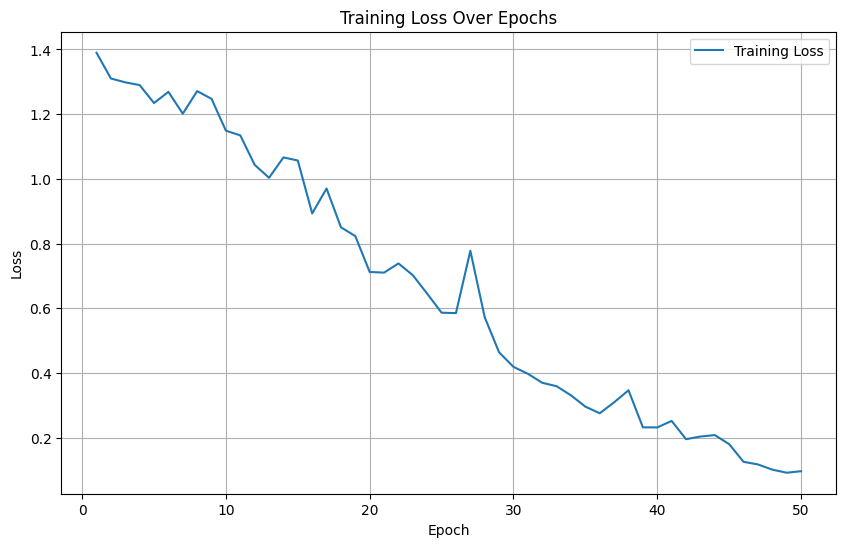

Test Accuracy: 50.00%


In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Initialize the model, loss function, and optimizer
model = EarlyFusionModel()  # or EarlyFusionModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Move model to the appropriate device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training loop
epochs = 50
train_losses = []  # To store loss values for each epoch

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        # Move data to the same device as the model
        text_batch, image_batch, label_batch = batch
        text_batch, image_batch, label_batch = text_batch.to(device), image_batch.to(device), label_batch.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(text_batch, image_batch)

        # Compute loss
        loss = criterion(output, label_batch)
        running_loss += loss.item()

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()

    # Average loss for this epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}')

# Plotting the training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

# Evaluation on the test set
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        text_batch, image_batch, label_batch = batch
        text_batch, image_batch, label_batch = text_batch.to(device), image_batch.to(device), label_batch.to(device)

        # Forward pass
        output = model(text_batch, image_batch)

        # Predicted labels
        _, predicted = torch.max(output, 1)
        total += label_batch.size(0)
        correct += (predicted == label_batch).sum().item()

# Print the test accuracy
accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')


Epoch 1/50, Loss: 1.3892
Epoch 2/50, Loss: 1.3433
Epoch 3/50, Loss: 1.2743
Epoch 4/50, Loss: 1.2969
Epoch 5/50, Loss: 1.2305
Epoch 6/50, Loss: 1.2865
Epoch 7/50, Loss: 1.2275
Epoch 8/50, Loss: 1.2486
Epoch 9/50, Loss: 1.1506
Epoch 10/50, Loss: 1.1874
Epoch 11/50, Loss: 1.1389
Epoch 12/50, Loss: 1.2373
Epoch 13/50, Loss: 1.0716
Epoch 14/50, Loss: 1.0567
Epoch 15/50, Loss: 0.9994
Epoch 16/50, Loss: 0.9599
Epoch 17/50, Loss: 0.9571
Epoch 18/50, Loss: 0.8754
Epoch 19/50, Loss: 0.8608
Epoch 20/50, Loss: 0.8221
Epoch 21/50, Loss: 0.9014
Epoch 22/50, Loss: 0.8537
Epoch 23/50, Loss: 0.7178
Epoch 24/50, Loss: 0.6436
Epoch 25/50, Loss: 0.6515
Epoch 26/50, Loss: 0.6717
Epoch 27/50, Loss: 0.5940
Epoch 28/50, Loss: 0.5294
Epoch 29/50, Loss: 0.5247
Epoch 30/50, Loss: 0.5116
Epoch 31/50, Loss: 0.4990
Epoch 32/50, Loss: 0.4114
Epoch 33/50, Loss: 0.3881
Epoch 34/50, Loss: 0.3556
Epoch 35/50, Loss: 0.3582
Epoch 36/50, Loss: 0.3790
Epoch 37/50, Loss: 0.3308
Epoch 38/50, Loss: 0.3432
Epoch 39/50, Loss: 0.

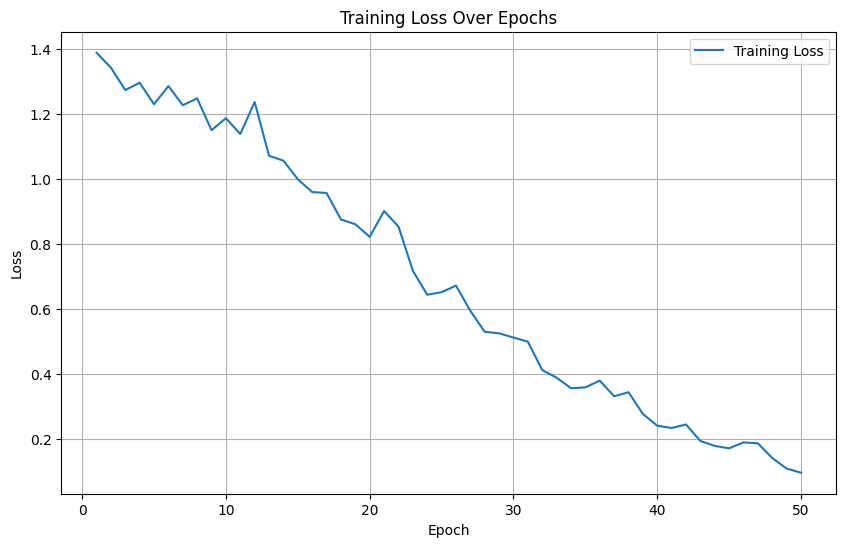

Test Accuracy: 42.00%


In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Initialize the model, loss function, and optimizer
model = LateFusionModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Move model to the appropriate device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training loop with loss tracking
epochs = 50
train_losses = []  # To store the training loss for each epoch

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        # Move data to the same device as the model
        text_batch, image_batch, label_batch = batch
        text_batch, image_batch, label_batch = text_batch.to(device), image_batch.to(device), label_batch.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(text_batch, image_batch)

        # Compute loss
        loss = criterion(output, label_batch)
        running_loss += loss.item()

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()

    # Average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}')

# Plotting the training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

# Evaluation on the test set
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        text_batch, image_batch, label_batch = batch
        text_batch, image_batch, label_batch = text_batch.to(device), image_batch.to(device), label_batch.to(device)

        # Forward pass
        output = model(text_batch, image_batch)

        # Predicted labels
        _, predicted = torch.max(output, 1)
        total += label_batch.size(0)
        correct += (predicted == label_batch).sum().item()

# Print the test accuracy
accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')
